# Compare Ecowitt data AW005 with reference sensors from DGA, Chile

This notebook loads **Ecowitt** data from the repo., **reference sensor** file from the repo., and compares selected variables, computes metrics, and creates plots.

In [177]:
#@title 1) Install / import packages
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [178]:
#@title 2) User configuration
REPO_URL = "https://github.com/paulmunozpauta/VLIR_SI_EC_2025-2027"
REPO_BRANCH = "main"
REPO_DIR = "/content/VLIR_SI_EC_2025-2027"
# Clone or update repo
if not os.path.exists(REPO_DIR):
    !git clone --branch $REPO_BRANCH $REPO_URL $REPO_DIR
else:
    %cd $REPO_DIR
    !git pull
ECOWITT_FILE = "datasets/AW005.csv"
REFERENCE_FILE = "Validation_meteo/DGA_ChillanUdeC.xlsx"

/content/VLIR_SI_EC_2025-2027
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (20/20), 1.85 KiB | 57.00 KiB/s, done.
From https://github.com/paulmunozpauta/VLIR_SI_EC_2025-2027
   780658e3e..6aa29c079  main       -> origin/main
Updating 780658e3e..6aa29c079
Fast-forward
 datasets/AW001.csv | 1 +
 datasets/AW002.csv | 1 +
 datasets/AW003.csv | 1 +
 datasets/AW004.csv | 1 +
 datasets/AW005.csv | 1 +
 5 files changed, 5 insertions(+)


In [179]:
#@title 3) Load Ecowitt data

ecowitt_path = os.path.join(REPO_DIR, ECOWITT_FILE)

ecowitt_columns = [
    "Date",
    "air_temperature_c",
    "relative_humidity_pct",
    "dew_point_c",
    "feels_like_c",
    "wind_speed_kmh",
    "wind_gust_kmh",
    "wind_direction_deg",
    "atmospheric_pressure_inhg",
    "rain_rate_mm_hr",
    "hourly_rain_mm",
    "solar_radiation_w_m2",
    "uv_index",
    "indoor_temperature_c",
    "indoor_relative_humidity_pct"
]

ecowitt = pd.read_csv(
    ecowitt_path,
    names=ecowitt_columns,
    header=0
)

# Datetime
ecowitt["Date"] = pd.to_datetime(
    ecowitt["Date"],
    errors="coerce",
    utc=True
)

ecowitt = ecowitt.dropna(subset=["Date"])

# Numeric conversion
for col in ecowitt.columns:

    if col != "Date":

        ecowitt[col] = pd.to_numeric(
            ecowitt[col],
            errors="coerce"
        )

# Convert wind from km/h to m/s
ecowitt["wind_speed_ms"] = (
    ecowitt["wind_speed_kmh"] / 3.6
)

ecowitt["wind_gust_ms"] = (
    ecowitt["wind_gust_kmh"] / 3.6
)

# Remove original km/h columns
ecowitt = ecowitt.drop(columns=[
    "wind_speed_kmh",
    "wind_gust_kmh"
])

# Convert pressure from inHg to hPa
ecowitt["atmospheric_pressure_hpa"] = (
    ecowitt["atmospheric_pressure_inhg"] * 33.8639
)

# Correct relative pressure -> approximate absolute pressure
ecowitt["atmospheric_pressure_hpa"] = (
    ecowitt["atmospheric_pressure_hpa"] - 8.9
)

# Remove original pressure column
ecowitt = ecowitt.drop(
    columns=["atmospheric_pressure_inhg"]
)

# Index
ecowitt = ecowitt.set_index("Date")

# Sort chronologically
ecowitt = ecowitt.sort_index()

print(ecowitt.shape)

display(ecowitt.head())

(3377, 14)


,air_temperature_c,relative_humidity_pct,dew_point_c,feels_like_c,wind_direction_deg,rain_rate_mm_hr,hourly_rain_mm,solar_radiation_w_m2,uv_index,indoor_temperature_c,indoor_relative_humidity_pct,wind_speed_ms,wind_gust_ms,atmospheric_pressure_hpa
Date,,,,,,,,,,,,,,
2025-12-22 19:01:17.852000+00:00,26.3,40.0,11.6,26.3,127.0,0.0,0.8,2.1,0.0,26.1,40.0,0.0,0.0,1003.969249
2025-12-22 20:01:17.232000+00:00,26.9,36.0,10.6,26.6,245.0,0.0,0.3,1.9,0.0,26.7,37.0,0.0,0.0,1003.630610
2025-12-22 21:01:18.421000+00:00,26.8,36.0,10.5,26.5,245.0,0.0,0.3,1.7,0.0,26.4,36.0,0.0,0.0,1003.969249
2025-12-22 22:01:14.613000+00:00,26.5,35.0,9.8,26.5,245.0,0.0,0.3,1.4,0.0,26.1,35.0,0.0,0.0,1003.969249
2025-12-22 23:00:30.608000+00:00,26.0,36.0,9.8,26.0,245.0,0.0,0.3,1.0,0.0,25.5,36.0,0.0,0.0,1004.985166


In [180]:
#@title 4) Load reference data

reference_path = os.path.join(
    REPO_DIR,
    REFERENCE_FILE
)

reference = pd.read_excel(
    reference_path,
    header=1
)

# Rename datetime column
reference = reference.rename(columns={
    "Unnamed: 0": "Date"
})

# Convert datetime
reference["Date"] = pd.to_datetime(
    reference["Date"],
    errors="coerce"
)

# Remove invalid dates
reference = reference.dropna(subset=["Date"])

# Make datetime index
reference = reference.set_index("Date")

# Rename columns
reference = reference.rename(columns={

    "Pptación Acum. (mm)": "precipitation_mm",

    "Temp.del Aire (ºC)": "air_temperature_c",

    "Humedad (%)": "relative_humidity_pct",

    "Rad.Solar (Watt/m2)": "solar_radiation_w_m2",

    "Presión Atmosférica (mb)": "atmospheric_pressure_hpa",

    "Pp. acum. disdrometro (mm)": "disdrometer_precipitation_mm",

    "Direccion del Viento (grados)": "wind_direction_deg",

    "Velocidad del Vto. (m/s)": "wind_speed_ms",

    "Calidad de señal (db)": "signal_quality_db",

    "Pp. instan. disdrometro (mm)": "disdrometer_instantaneous_rainfall_mm",

    "Tipo Pptacion disdrometro ( )": "disdrometer_precipitation_type"

})

# Convert numeric columns
for col in reference.columns:

    if col != "disdrometer_precipitation_type":

        reference[col] = pd.to_numeric(
            reference[col],
            errors="coerce"
        )

# Sort chronologically
reference = reference.sort_index()

print(reference.shape)

display(reference.head())

(7860, 10)


,precipitation_mm,air_temperature_c,relative_humidity_pct,solar_radiation_w_m2,wind_direction_deg,atmospheric_pressure_hpa,wind_speed_ms,disdrometer_precipitation_mm,disdrometer_instantaneous_rainfall_mm,disdrometer_precipitation_type
Date,,,,,,,,,,
2025-12-01 00:00:00,597.3,12.2,84.4,0.0,0.0,1004.1,0.0,613.2,0.0,0
2025-12-01 00:30:00,597.3,11.7,88.4,0.0,180.0,1004.3,0.4,613.2,0.0,0
2025-12-01 01:00:00,597.3,10.9,89.0,0.0,0.0,1004.2,0.0,613.2,0.0,0
2025-12-01 01:30:00,597.3,10.9,90.7,0.0,0.0,1003.8,0.0,613.2,0.0,0
2025-12-01 02:00:00,597.3,10.5,91.5,0.0,186.2,1003.6,0.4,613.2,0.0,0


In [181]:
#@title 5) Resample reference hourly

agg_rules = {}

for col in reference.columns:

    if col in [
        "precipitation_mm",
        "disdrometer_precipitation_mm",
        "disdrometer_instantaneous_rainfall_mm"
    ]:
        agg_rules[col] = "sum"

    elif col == "solar_radiation_w_m2":
        agg_rules[col] = "max"

    elif col == "disdrometer_precipitation_type":
        agg_rules[col] = "last"

    else:
        agg_rules[col] = "mean"

reference_hourly = reference.resample("1H").agg(agg_rules)

# Remove fully empty rows
reference_hourly = reference_hourly.dropna(how="all")

print(reference_hourly.shape)

display(reference_hourly.head())

(3933, 10)


/tmp/ipykernel_674/450769328.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  reference_hourly = reference.resample("1H").agg(agg_rules)


,precipitation_mm,air_temperature_c,relative_humidity_pct,solar_radiation_w_m2,wind_direction_deg,atmospheric_pressure_hpa,wind_speed_ms,disdrometer_precipitation_mm,disdrometer_instantaneous_rainfall_mm,disdrometer_precipitation_type
Date,,,,,,,,,,
2025-12-01 00:00:00,1194.6,11.95,86.40,0.0,90.00,1004.2,0.20,1226.4,0.0,0
2025-12-01 01:00:00,1194.6,10.90,89.85,0.0,0.00,1004.0,0.00,1226.4,0.0,0
2025-12-01 02:00:00,1194.6,10.30,91.80,0.0,186.50,1003.6,0.45,1226.4,0.0,0
2025-12-01 03:00:00,1194.6,9.40,93.05,0.0,45.05,1003.6,0.25,1226.4,0.0,0
2025-12-01 04:00:00,1194.6,8.65,93.70,0.0,0.00,1003.1,0.00,1226.4,0.0,0


In [182]:
#@title 6) Merge Ecowitt and reference

# Ecowitt already UTC
ecowitt.index = pd.to_datetime(
    ecowitt.index,
    utc=True
)

# Reference is Chile local time
reference_hourly.index = (
    pd.to_datetime(reference_hourly.index)
    .tz_localize(
        "America/Santiago",
        ambiguous=False
    )
    .tz_convert("UTC")
)

comparison = pd.merge_asof(
    ecowitt.sort_index(),
    reference_hourly.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest",
    tolerance=pd.Timedelta("30min"),
    suffixes=("_ecowitt", "_reference")
)

print(comparison.shape)

display(comparison.tail(10))

(3377, 24)


,air_temperature_c_ecowitt,relative_humidity_pct_ecowitt,dew_point_c,feels_like_c,wind_direction_deg_ecowitt,rain_rate_mm_hr,hourly_rain_mm,solar_radiation_w_m2_ecowitt,uv_index,indoor_temperature_c,...,precipitation_mm,air_temperature_c_reference,relative_humidity_pct_reference,solar_radiation_w_m2_reference,wind_direction_deg_reference,atmospheric_pressure_hpa_reference,wind_speed_ms_reference,disdrometer_precipitation_mm,disdrometer_instantaneous_rainfall_mm,disdrometer_precipitation_type
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-13 18:01:07.914000+00:00,15.6,76.0,11.4,15.6,187.0,0.0,0.0,239.3,2.0,23.4,...,427.6,17.80,71.05,234.4,247.10,1002.20,1.00,1537.6,0.0,0.0
2026-05-13 19:01:07.548000+00:00,17.4,69.0,11.7,17.4,156.0,0.0,0.0,199.2,1.0,24.9,...,427.6,19.15,63.95,203.4,195.85,1001.75,1.70,1537.6,0.0,0.0
2026-05-13 20:01:08.104000+00:00,18.3,63.0,11.1,18.3,179.0,0.0,0.0,150.1,1.0,25.0,...,427.6,19.50,61.55,169.6,204.75,1001.70,1.55,1537.6,0.0,0.0
2026-05-13 21:01:09.778000+00:00,17.7,65.0,11.1,17.7,141.0,0.0,0.0,47.5,0.0,23.1,...,427.6,18.05,65.40,115.4,226.10,1001.85,1.40,1537.6,0.0,0.0
2026-05-13 22:01:07.506000+00:00,15.8,68.0,9.9,15.8,208.0,0.0,0.0,0.9,0.0,19.6,...,427.6,15.20,69.40,0.0,233.35,1002.05,0.70,1537.6,0.0,0.0
2026-05-13 23:01:07.611000+00:00,13.4,71.0,8.2,13.4,305.0,0.0,0.0,0.0,0.0,15.9,...,427.6,12.85,73.05,0.0,221.80,1002.50,0.45,1537.6,0.0,0.0
2026-05-14 00:01:06.465000+00:00,12.4,71.0,7.3,12.4,164.0,0.0,0.0,0.0,0.0,14.2,...,213.8,12.20,73.70,0.0,207.50,1002.60,0.90,768.8,0.0,0.0
2026-05-14 01:01:06.378000+00:00,11.3,76.0,7.2,11.3,193.0,0.0,0.0,0.0,0.0,13.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-14 02:01:06.906000+00:00,10.4,82.0,7.4,10.4,224.0,0.0,0.0,0.0,0.0,12.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [183]:
#@title 7) Check overlap after merge

print("Ecowitt period:")
print(ecowitt.index.min(), "to", ecowitt.index.max())

print("\nReference period:")
print(reference_hourly.index.min(), "to", reference_hourly.index.max())

print("\nComparison non-null reference rows:")
ref_cols = [c for c in comparison.columns if c.endswith("_reference")]
print(comparison[ref_cols].dropna(how="all").shape[0], "rows with reference data")

Ecowitt period:
2025-12-22 19:01:17.852000+00:00 to 2026-05-14 03:01:07.944000+00:00

Reference period:
2025-12-01 03:00:00+00:00 to 2026-05-14 00:00:00+00:00

Comparison non-null reference rows:
3373 rows with reference data


In [184]:
#@title 8) Compute metrics

variables = [
    "air_temperature_c",
    "relative_humidity_pct",
    "solar_radiation_w_m2",
    "wind_speed_ms",
    "atmospheric_pressure_hpa"
]

metrics = []

for var in variables:
    eco = f"{var}_ecowitt"
    ref = f"{var}_reference"

    if eco not in comparison.columns or ref not in comparison.columns:
        print(f"Skipping {var}: missing columns")
        continue

    tmp = comparison[[eco, ref]].dropna()

    if tmp.empty:
        print(f"Skipping {var}: no paired data")
        continue

    y_true = tmp[ref]
    y_pred = tmp[eco]

    metrics.append({
        "variable": var,
        "n": len(tmp),
        "bias": (y_pred - y_true).mean(),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "corr": np.corrcoef(y_true, y_pred)[0, 1]
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

,variable,n,bias,mae,rmse,r2,corr
0,air_temperature_c,3364,-0.655098,0.954682,1.370316,0.967774,0.988301
1,relative_humidity_pct,3364,0.149747,2.571775,3.580265,0.972782,0.986774
2,solar_radiation_w_m2,3364,72.393876,92.533948,171.378456,-0.593064,0.917694
3,wind_speed_ms,3364,-0.341478,0.553943,0.784523,0.622098,0.841004
4,atmospheric_pressure_hpa,3364,1.642340,1.975805,2.116812,0.571601,0.915377


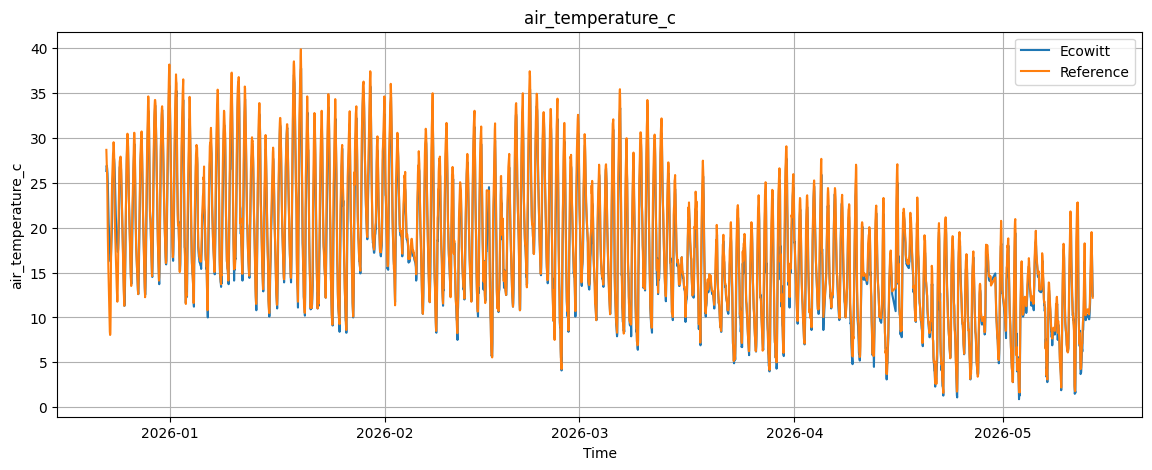

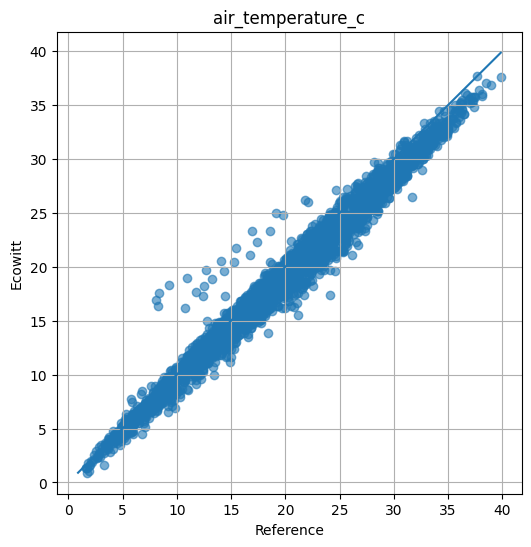

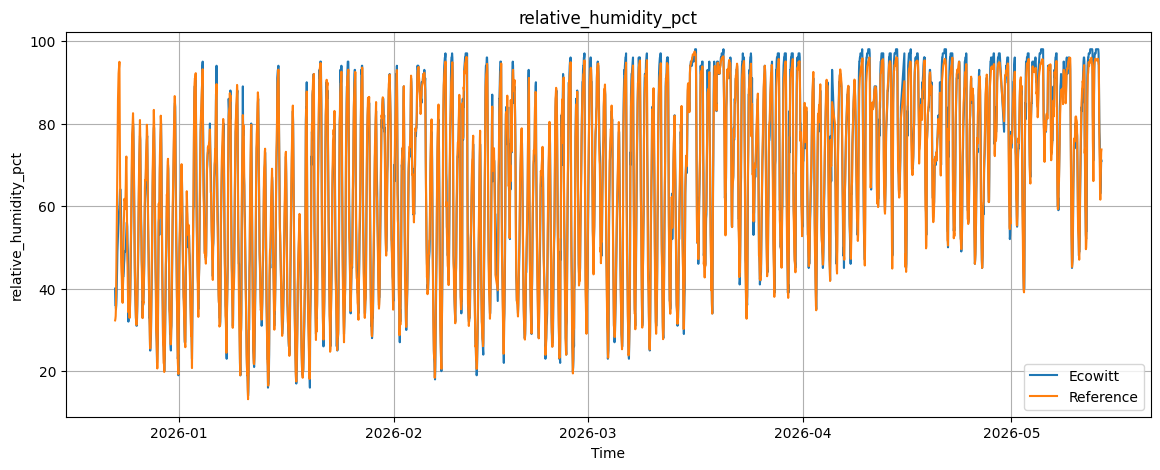

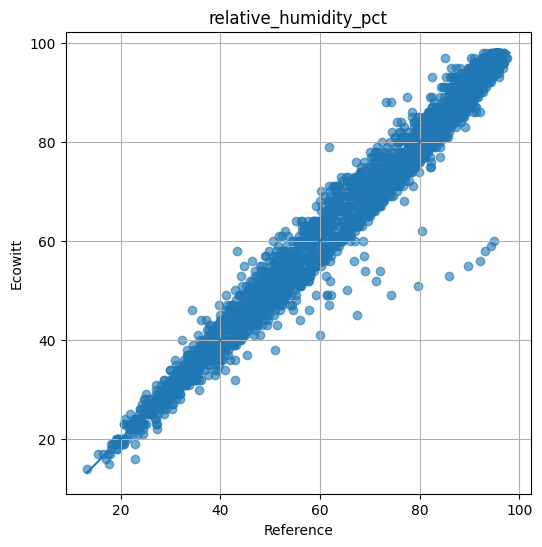

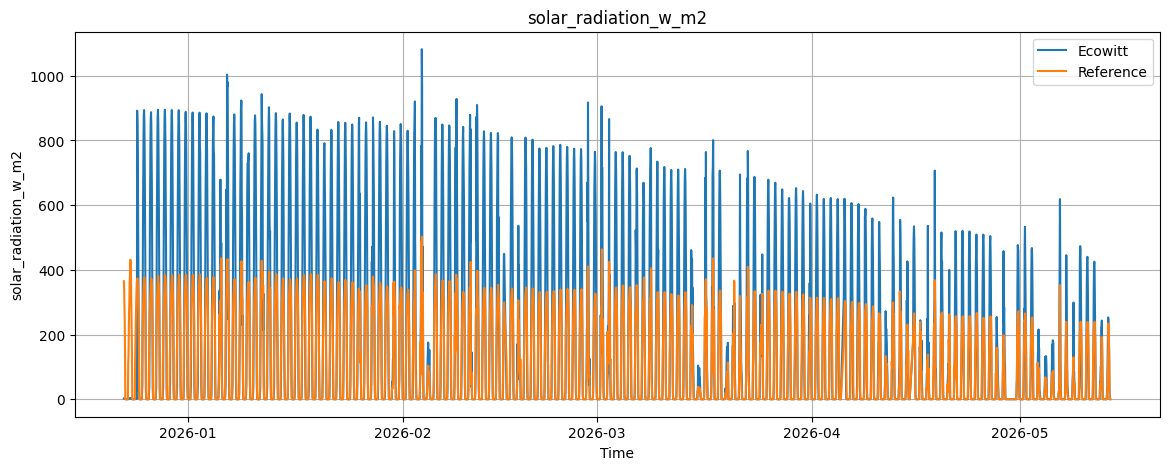

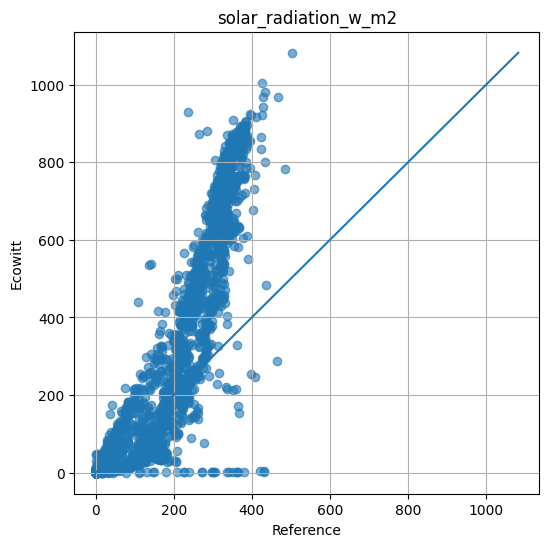

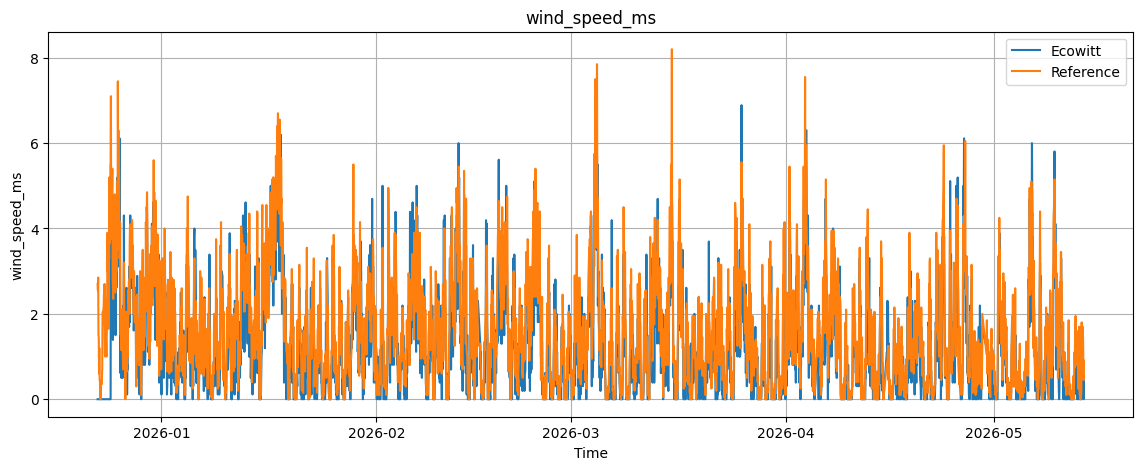

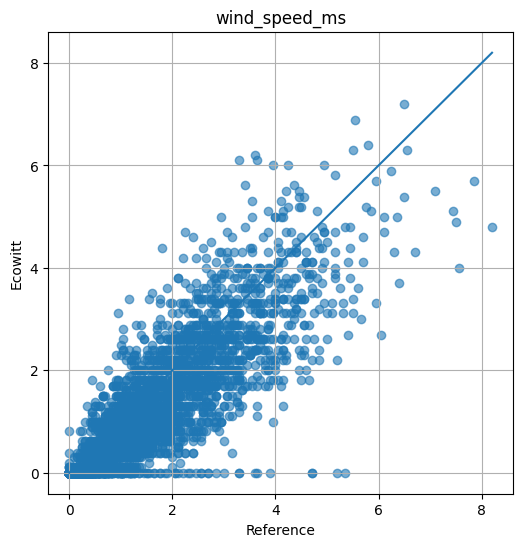

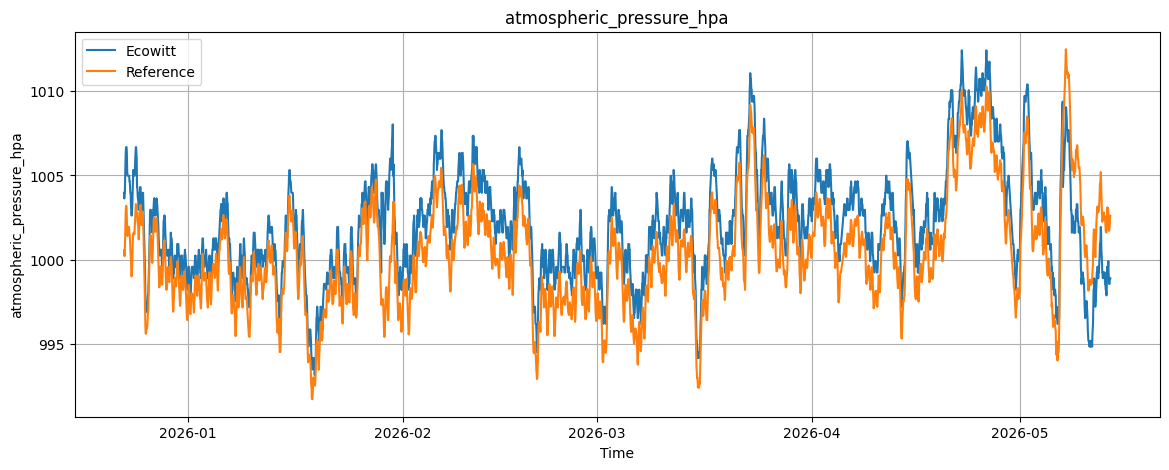

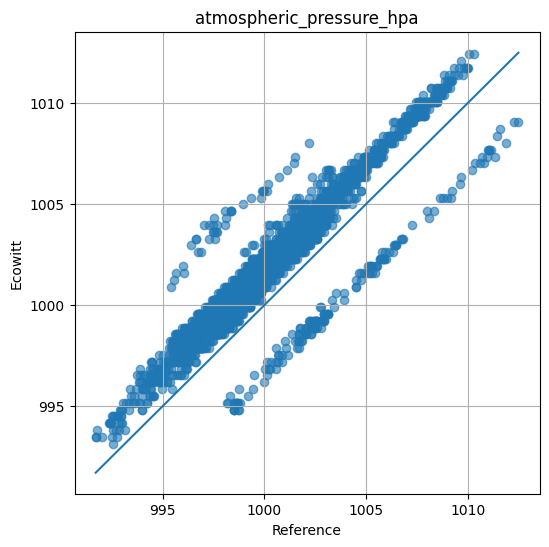

In [185]:
#@title 9) Plot comparisons

for var in variables:
    eco = f"{var}_ecowitt"
    ref = f"{var}_reference"

    if eco not in comparison.columns or ref not in comparison.columns:
        continue

    tmp = comparison[[eco, ref]].dropna()

    if tmp.empty:
        continue

    plt.figure(figsize=(14, 5))
    plt.plot(tmp.index, tmp[eco], label="Ecowitt")
    plt.plot(tmp.index, tmp[ref], label="Reference")
    plt.title(var)
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(tmp[ref], tmp[eco], alpha=0.6)

    mn = min(tmp[ref].min(), tmp[eco].min())
    mx = max(tmp[ref].max(), tmp[eco].max())

    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Reference")
    plt.ylabel("Ecowitt")
    plt.title(var)
    plt.grid(True)
    plt.show()

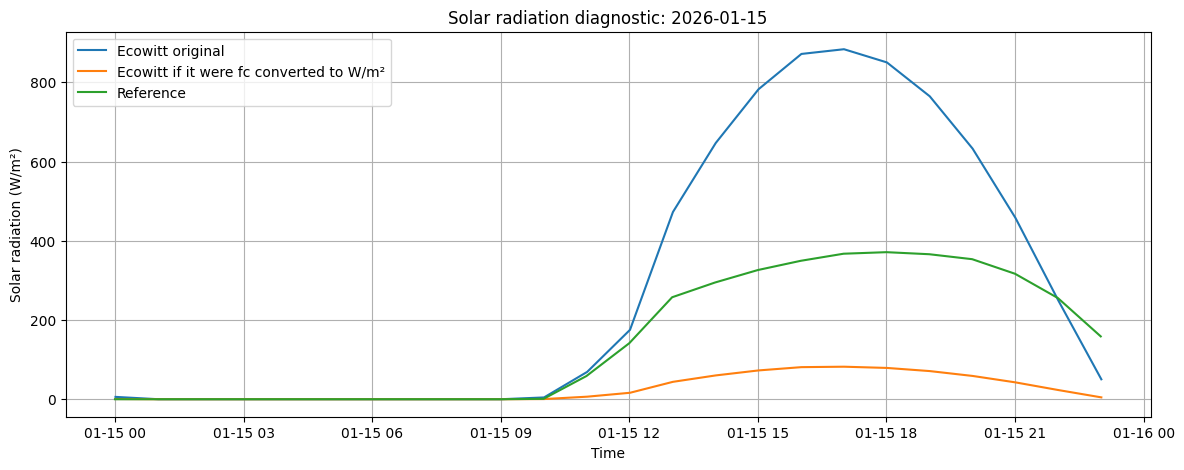

Daily max values
Ecowitt original: 883.5
Ecowitt fc→W/m²: 82.07715
Reference: 371.2


In [186]:
#@title Solar unit/exposure diagnostic

# Choose a clear day to inspect
DAY = "2026-01-15"

eco_day = ecowitt.loc[DAY]
ref_day = reference_hourly.loc[DAY]

plt.figure(figsize=(14, 5))
plt.plot(
    eco_day.index,
    eco_day["solar_radiation_w_m2"],
    label="Ecowitt original"
)

plt.plot(
    eco_day.index,
    eco_day["solar_radiation_w_m2"] * 0.0929,
    label="Ecowitt if it were fc converted to W/m²"
)

plt.plot(
    ref_day.index,
    ref_day["solar_radiation_w_m2"],
    label="Reference"
)

plt.title(f"Solar radiation diagnostic: {DAY}")
plt.ylabel("Solar radiation (W/m²)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

print("Daily max values")
print("Ecowitt original:", eco_day["solar_radiation_w_m2"].max())
print("Ecowitt fc→W/m²:", (eco_day["solar_radiation_w_m2"] * 0.0929).max())
print("Reference:", ref_day["solar_radiation_w_m2"].max())